# <font color="green"> **AI for Cybersecurity Project 2024-25 Group 9**

<font color="black">
Lamb Giovanni - 0622702168 <br>
Orlando Palma - 0622702433 <br>
Saturnino Fabrizio - 0622702328 <br>
Zottarelli Egidio - 0622702175

## **Contents**
1. [Dataset Generation](#dataset_generation)
2. [Detector: ResNet50](#detector)
3. [Comparative Analysis](#analysis)

In [ ]:
%%capture
!pip install facenet-pytorch
!pip install adversarial-robustness-toolbox[all]

## **Import**

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models
import torch.nn as nn


from tqdm import tqdm
from torch.utils.data import Subset, DataLoader
from torch.utils.data import random_split
from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split
from torch.nn import BCELoss, Sigmoid
from art.estimators.classification import PyTorchClassifier
from facenet_pytorch import InceptionResnetV1
from art.attacks.evasion import FastGradientMethod, BasicIterativeMethod, ProjectedGradientDescent, CarliniLInfMethod, CarliniL2Method, DeepFool
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


<a id="dataset_generation"></a>
## **1. Dataset generation (clean + adversarial samples)**

In this section, we describe the process of generating a comprehensive dataset composed of both clean and adversarial face images, which will later be used to train and evaluate an adversarial sample detector. Starting from an initial set of 1,000 clean test samples, we apply a range of well-established adversarial attack techniques to generate 1,000 corresponding adversarial examples.

The attacks used include both untargeted (e.g., FGSM, BIM, PGD, DeepFool, Carlini & Wagner L∞) and targeted (e.g., FGSM, BIM, PGD, Carlini & Wagner L2) methods. Each of these is configured with specific parameters and applied to randomly selected inputs to produce realistic and diverse adversarial perturbations. These perturbations aim to mislead the face recognition model (based on the InceptionResnetV1 architecture pre-trained on the VGGFace2 dataset) without introducing perceptible changes to human observers.

The resulting clean and adversarial samples are then merged into a single dataset, and binary labels are assigned: 0 for clean inputs and 1 for adversarial ones. This labeled dataset is subsequently split into training and test subsets and formatted for input into PyTorch, enabling the training of a binary classifier capable of distinguishing between benign and malicious inputs.

In [ ]:
# Loading clean dataset
x_test = np.load('datsets/x_test_32.npy')
y_test = np.load('datasets/y_test_32.npy')

In [ ]:
# Definition of attacks used to create adversarial samples

def get_untargeted_attacks(classifier):
    """
    Returns a dictionary of untargeted adversarial attack instances for the given classifier.

    Parameters:
    - classifier: The model wrapped as an ART PyTorchClassifier.

    Returns:
    - dict: Attack name as key, attack instance as value.
    """
    return {
        # Fast Gradient Sign Method (FGSM)
        # eps: attack step size, targeted: False for untargeted attack
        "FGSM_Untargeted": FastGradientMethod(estimator=classifier, eps=0.1, targeted=False),

        # Basic Iterative Method (BIM)
        # eps: max perturbation, eps_step: step size per iteration, max_iter: number of iterations
        "BIM_Untargeted": BasicIterativeMethod(estimator=classifier, eps=0.1, eps_step=0.001, max_iter=100, targeted=False),

        # Projected Gradient Descent (PGD)
        # eps: max perturbation, eps_step: step size, max_iter: iterations, num_random_init: random initializations
        "PGD_Untargeted": ProjectedGradientDescent(estimator=classifier, eps=0.1, eps_step=0.01, max_iter=10, num_random_init=0, targeted=False),

        # Carlini & Wagner L-infinity attack
        # initial_const: initial trade-off constant, confidence: confidence of adversarial examples,
        # learning_rate: optimizer step size, max_iter: number of iterations
        "Carlini-Wagner_Untargeted": CarliniLInfMethod(classifier=classifier, initial_const=1, confidence=0.1, learning_rate=0.1, max_iter=1, targeted=False),

        # DeepFool attack
        # epsilon: overshoot parameter, max_iter: max iterations, nb_grads: number of gradients, batch_size: batch size
        "DeepFool": DeepFool(classifier=classifier, epsilon=1e-6, max_iter=1, nb_grads=8, batch_size=20)
    }


def get_targeted_attacks(classifier):
    """
    Returns a dictionary of targeted adversarial attack instances for the given classifier.

    Parameters:
    - classifier: The model wrapped as an ART PyTorchClassifier.

    Returns:
    - dict: Attack name as key, attack instance as value.
    """
    return {
        # FGSM with targeted=True
        "FGSM_Targeted": FastGradientMethod(estimator=classifier, eps=0.1, targeted=True),

        # BIM with targeted=True
        "BIM_Targeted": BasicIterativeMethod(estimator=classifier, eps=0.1, eps_step=0.001, max_iter=100, targeted=True),

        # PGD with targeted=True
        "PGD_Targeted": ProjectedGradientDescent(estimator=classifier, eps=0.1, eps_step=0.01, max_iter=10, num_random_init=0, targeted=True),

        # Carlini & Wagner L2 attack for targeted attacks
        "Carlini-Wagner_Targeted": CarliniL2Method(classifier=classifier, initial_const=1, confidence=0.1, learning_rate=0.1, max_iter=1, targeted=True)
    }

In [ ]:
# Definition number of adversarial samples per attack 

untargeted_iterations = {
        "FGSM_Untargeted": 125,
        "BIM_Untargeted": 125,
        "PGD_Untargeted": 125,
        "Carlini-Wagner_Untargeted": 75,
        "DeepFool": 100
    }

targeted_iterations = {
        "FGSM_Targeted": 125,
        "BIM_Targeted": 125,
        "PGD_Targeted": 125,
        "Carlini-Wagner_Targeted": 75
    }

In [ ]:
def adv_samples(x_clean, y_clean, classifier):
    """
    Generates adversarial samples.

    Parameters:
    - x_clean (np.ndarray): Clean input samples.
    - y_clean (np.ndarray): Corresponding true labels for the input samples.
    - classifier: A trained classifier model compatible with the attack methods.

    Returns:
    - x_adv (np.ndarray): Adversarial examples generated from the clean inputs.
    - y_adv (np.ndarray): Labels associated with the adversarial examples.

    Function Behavior:
    - Retrieves a set of untargeted and targeted adversarial attack methods for the given classifier.
    - For each untargeted attack:
        - Randomly selects samples from the input set and applies the attack.
        - Stores the resulting adversarial examples and their original labels.
    - For each targeted attack:
        - Randomly selects a source and a target sample.
        - Generates adversarial examples intended to be misclassified as the target label.
        - Stores the adversarial samples and the target labels.
    - Returns the combined list of all generated adversarial samples and corresponding labels.
    """

    x_adv, y_adv = [], []
    num_classes = 8631

    untargeted = get_untargeted_attacks(classifier)
    targeted = get_targeted_attacks(classifier)

    for name, attack in untargeted.items():
            print(f"Running {name} attack")
            for _ in range(untargeted_iterations.get(name, 100)):
                idx = np.random.choice(len(x_clean))
                x_sample = np.expand_dims(x_clean[idx], axis=0)
                y_sample = y_clean[idx]
                x_adv_sample = attack.generate(x=x_sample)
                x_adv.append(np.squeeze(x_adv_sample, axis=0))
                y_adv.append(y_sample)
            print(f"{name} attack completed")

    for name, attack in targeted.items():
        print(f"Running {name} attack")
        for _ in range(targeted_iterations.get(name, 100)):
            idx1, idx2 = np.random.choice(len(x_clean), size=2, replace=False)
            x_target = np.expand_dims(x_clean[idx2], axis=0)
            y_target = y_clean[idx2]
            y_sample = y_clean[idx1]

            y_target_class = np.random.randint(1, num_classes)
            while y_target_class == y_sample:
                y_target_class = np.random.randint(1, num_classes)
            y_target_class = np.array([y_target_class])

            x_adv_targeted_sample = attack.generate(x=x_target, y=y_target_class)
            x_adv.append(np.squeeze(x_adv_targeted_sample, axis=0))
            y_adv.append(y_target)
        print(f"{name} attack completed")

    return np.array(x_adv), np.array(y_adv)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nn1 = InceptionResnetV1(pretrained='vggface2').eval().to(device)
nn1.classify = True
target_class = 1050
num_classes = 8631

# Defining the classifier to be attached
classifier = PyTorchClassifier(
    model=nn1,                                                     # The PyTorch model to use
    clip_values=(-1, 1),                                           # The minimum and maximum values of the input
    loss=torch.nn.CrossEntropyLoss(),                              # The loss function
    optimizer=torch.optim.Adam(nn1.parameters(), lr=0.001),        # The optimizer
    input_shape=(3, 160, 160),                                     # The shape of the input
    nb_classes=num_classes,                                        # The number of classes
)

In [ ]:
# Generation of adversarial samples
x_adv, y_adv = adv_samples(x_test, y_test, classifier)

In [ ]:
print(f"Length of x_test: {len(x_test)}")
print(f"Length of y_test: {len(y_test)}")
print(f"Length of x_adv:  {len(x_adv)}")
print(f"Length of y_adv:  {len(y_adv)}")

In [ ]:
# Saving adversarial sample

np.save('datasets/x_adv_detector.npy', x_adv)
np.save('datsets/y_adv_detector.npy', y_adv)

In [3]:
x_test = np.load('datasets/x_test_32.npy')
y_test = np.load('datasets/y_test_32.npy')

x_adv = np.load('datasets/x_adv_detector.npy')
y_adv = np.load('datasets/y_adv_detector.npy')

In [4]:
# Combining both sets into a single dataset that includes both normal and adversarial inputs.
detector_x = np.concatenate((x_test, x_adv))
detector_y = np.concatenate((y_test, y_adv))

#Creates binary labels for the detector: 0 for clean samples, 1 for adversarial samples
labels_normal = np.zeros(int(len(detector_y)/2))
labels_adversarial = np.ones(int(len(detector_y)/2))

labels = np.concatenate((labels_normal, labels_adversarial))

In [5]:
# Splitting the dataset in training and test
x_det_train, x_det_test, y_det_train, y_det_test, labels_train, labels_test = train_test_split(
    detector_x, detector_y, labels, test_size=0.2, random_state=42, stratify=labels
)

# Converting training data to PyTorch tensor
X_tensor = torch.tensor(x_det_train)
y_tensor = torch.tensor(labels_train)

# Creating a PyTorch dataset
train_dataset = TensorDataset(X_tensor, y_tensor)


<a id="detector"></a>
## **2. Detector: Resnet50**

In this section, we describe the design and training of the model used to detect adversarial examples. We adopt a transfer learning approach based on the ResNet50 convolutional neural network, a well-established architecture pre-trained on ImageNet. The model is repurposed for binary classification (clean vs. adversarial) by replacing its final fully connected layer with a single-unit output followed by a sigmoid activation function.

To preserve the rich feature representations learned by the pre-trained model, all layers except the final classification head are frozen during training. This allows for efficient fine-tuning on our adversarial detection task with reduced computational cost and risk of overfitting.

Training is carried out using binary cross-entropy loss and stochastic gradient descent (SGD) with momentum. The dataset, previously constructed with balanced clean and adversarial samples, is split into training and validation subsets using K-fold cross-validation (or a simple split when K=1). Each fold is trained independently, with early stopping employed to prevent overfitting and retain the best-performing model based on validation loss.

In [ ]:
def build_adv_detector(num_output=1):
    """
    Builds an adversarial sample detector model based on a pre-trained ResNet50.

    Parameters:
    - num_output (int): Number of output units for the final fully connected layer.
      Use 1 for binary classification (adversarial vs. clean), or more for multi-class.

    Returns:
    - model (torch.nn.Module): The constructed PyTorch model ready for training.
    """
    # Definition of the pre-trained CNN network
    model = models.resnet50(pretrained=True)

    # Freeze the weights of the pre-trained network, except for the last layer
    for name, param in model.named_parameters():
        if not name.startswith('fc'):
            param.requires_grad = False

    # Replace the last fully connected layer with a linear layer
    # having the number of input features equal to those of the output from the previous layer,
    # and the number of output features set to num_output (default 1 for binary classification)
    model.fc = nn.Linear(model.fc.in_features, num_output)

    return model

In [7]:
model = build_adv_detector(1)

c:\Users\Utente\Desktop\AI For Cybersecurity\Code\AIenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utente\Desktop\AI For Cybersecurity\Code\AIenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Utente/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:15<00:00, 6.49MB/s]


In [ ]:
# Definition of model parameters
loss_function = BCELoss()  # Binary Cross Entropy Loss
output_activation = Sigmoid()  # Sigmoid activation for the last layer

# Training parameters
batch_size = 32
learning_rate = 0.001
momentum = 0.9
lambda_reg = 0
epochs = 30
early_stopping_patience = 4
K_cross_val = 1

# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Network parameters
num_output = 1  # Number of classes for the classification problem

# Create output directory and logger
experiment_name = 'detector'
os.makedirs(experiment_name, exist_ok=True)



In [ ]:
def cross_val_dataloaders(train_dataset, val_dataset=None, K=10, batch_size=32):
  """
  Splits the dataset into K folds for cross-validation and returns DataLoaders for each fold.

  Parameters:
  - train_dataset: The dataset to be used for training (PyTorch Dataset).
  - val_dataset: The dataset to be used for validation (PyTorch Dataset). If None, uses train_dataset.
  - K: Number of folds for cross-validation. If K=1, performs a simple train/validation split.
  - batch_size: Batch size for the DataLoaders.

  Returns:
  - train_folds: List of DataLoaders for training folds.
  - val_folds: List of DataLoaders for validation folds.
  - indexes: Index tensor used for splitting (None if K=1).
  """
  if val_dataset is None:
    val_dataset = train_dataset

  dataloader_params = {"batch_size": batch_size, "num_workers": 2, "pin_memory": True}
  if K == 1:
    # If K = 1, perform a division of the data into training and validation using a specified proportion
    proportion = 0.2
    total_length = len(train_dataset)
    val_length = int(total_length * proportion)
    train_length = total_length - val_length

    train_dataset, val_dataset = random_split(train_dataset, [train_length, val_length])

    # Create DataLoader for training and validation
    train_fold = DataLoader(train_dataset, shuffle=True, **dataloader_params)
    val_fold = DataLoader(val_dataset, shuffle=False, **dataloader_params)

    return [train_fold], [val_fold], None
  else:
    indexes = torch.randperm(len(train_dataset)) % K  # Random sequence of unique indices with respect to module K
    train_folds, val_folds = [], []
    for k in range(K):
      val_fold = Subset(val_dataset, (indexes == k).nonzero().squeeze())
      train_fold = Subset(train_dataset, (indexes != k).nonzero().squeeze())

      val_fold = DataLoader(val_fold, shuffle=False, **dataloader_params)  # Shuffle False for validation
      train_fold = DataLoader(train_fold, shuffle=True, **dataloader_params)  # Shuffle True for training

      val_folds.append(val_fold)
      train_folds.append(train_fold)

    return train_folds, val_folds, indexes

In [ ]:
def one_epoch(model, lossFunction, output_activation, optimizer, train_loader, val_loader, epoch, device):
  """
  Trains and validates the model for one epoch.

  Parameters:
  - model: The PyTorch model to train.
  - lossFunction: The loss function used for optimization (e.g., BCELoss).
  - output_activation: Activation function applied to the model's output (e.g., Sigmoid).
  - optimizer: The optimizer used for updating model parameters (e.g., SGD, Adam).
  - train_loader: DataLoader for the training set.
  - val_loader: DataLoader for the validation set.
  - epoch: Current epoch number (for logging purposes).
  - device: Device to run the computations on ('cpu' or 'cuda').

  Returns:
  - val_loss: Average validation loss for the epoch.
  - val_accuracy: Average validation accuracy for the epoch.
  """

  model.to(device) # Move the model to the selected device

  model.train() # Set up the model for training

  i_start = epoch * len(train_loader)
  for i, (X, y) in tqdm(enumerate(train_loader), desc="epoch {} - train".format(epoch)):
    X = X.squeeze().to(device) # Dimensionality reduction to fit the input to the network
    y = y.to(device).float()

    optimizer.zero_grad()

    o = model(X)
    o = output_activation(o).squeeze()
    l = lossFunction(o, y)

    l.backward()
    optimizer.step()

    acc = ((o.detach() > .5) == y.detach()).float().mean()

    print("- batch loss and accuracy : {:.7f}\t{:.4f}".format(l.detach().item(), acc))

  model.eval() # Set up the model for evaluation
  with torch.no_grad():
    val_loss = []
    val_corr_pred = []
    for X, y in tqdm(val_loader, desc="epoch {} - validation".format(epoch)):

      X = X.squeeze().to(device)
      y = y.to(device).float()

      o = model(X)
      o = output_activation(o).squeeze()
      val_loss.append(lossFunction(o, y))
      val_corr_pred.append((o > .5) == y)

    val_loss = torch.stack(val_loss).mean().item()
    val_accuracy = torch.concatenate(val_corr_pred).float().mean().item()

    print("Validation loss and accuracy : {:.7f}\t{:.4f}".format(val_loss, val_accuracy))
  return val_loss, val_accuracy

In [ ]:
# Creating folders and saving the index in memory to optionally restore it
train_folds, val_folds, indexes = cross_val_dataloaders(train_dataset, None, K_cross_val, batch_size)
torch.save(indexes, os.path.join(experiment_name, "cross-val-indexes.pt"))

# Initialize variables with relative size
val_losses = torch.zeros(epochs, K_cross_val)
val_accuracies = torch.zeros(epochs, K_cross_val)

for k in range(K_cross_val):
    # Dataloader, network, optimizer for each fold
    train_loader, val_loader = train_folds[k], val_folds[k]
    model = build_adv_detector(num_output)
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(),
                                lr=learning_rate,
                                weight_decay=lambda_reg,
                                momentum=momentum)

    # Early stopping and best model saving
    early_stopping_counter = early_stopping_patience
    min_val_loss = float('inf')

    # Training and validation
    for e in range(epochs):
        print("FOLD {} - EPOCH {}".format(k, e))
        val_loss, val_accuracy = one_epoch(model, loss_function, output_activation, optimizer, train_loader, val_loader, e, device)

        # Store the validation metrics
        val_losses[e, k] = val_loss
        val_accuracies[e, k] = val_accuracy
        torch.save(val_losses, os.path.join(experiment_name, 'val_losses.pth'))
        torch.save(val_accuracies, os.path.join(experiment_name, 'val_accuracies.pth'))

        # Save the best model and check the early stopping criteria
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            early_stopping_counter = early_stopping_patience  # Reset early stopping counter
            torch.save(model.state_dict(), os.path.join(experiment_name, 'fold_{}_best_model.pth'.format(k)))
            print("- saved best model")

        if e > 0:  # Early stopping counter update
            if val_losses[e, k] > val_losses[e - 1, k]:
                early_stopping_counter -= 1  # Update early stopping counter
            else:
                early_stopping_counter = early_stopping_patience  # Reset early stopping counter
        if early_stopping_counter == 0:  # Early stopping
            break


<a id="analysis"></a>
## **3. Comparative Analysis**

In this section, we evaluate the performance of the adversarial detector and assess its impact on the overall robustness of the classification pipeline. The goal is twofold:

1. Evaluate the effectiveness of the detector in identifying adversarial versus clean examples.

2. Compare the performance of the downstream classifier when used with and without the adversarial detector as a preprocessing filter.

To assess the detector, we load the best-performing model from training and apply it to a held-out test set. We compute classification metrics such as accuracy, confusion matrix, and detailed performance reports, allowing us to quantify how well the detector distinguishes adversarial from non-adversarial samples.

Subsequently, we examine the behavior of the face recognition classifier under two scenarios:

1. Without detector: The classifier is tested directly on the full dataset, including both clean and adversarial samples.

2. With detector: The detector is used to filter out suspected adversarial inputs, and the classifier is applied only to those deemed clean.

This comparison highlights the added value of integrating a detection stage into the pipeline. By removing adversarial inputs, we aim to improve classification accuracy and increase system resilience against adversarial attacks. 

In [10]:
# Assuming model is defined elsewhere
model = build_adv_detector(1)

# Path to the saved weights
weights_path = 'detector/fold_0_best_model.pth'

# Load the weights into the model
model.load_state_dict(torch.load(weights_path))

# Set the model to evaluation mode
model.eval()

# Assuming x_det_test and labels_test are defined elsewhere
X_tensor_test = torch.tensor(x_det_test)
y_tensor_test = torch.tensor(labels_test)

# Create a TensorDataset
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)

# Set the output activation function
output_activation = nn.Sigmoid()

correct = 0
total_samples = len(test_dataset)
y_pred = []
with torch.no_grad():
    for X, y in test_dataset:
        # Forward pass
        o = model(X.unsqueeze(0))
        o = output_activation(o)

        # Calculate binary accuracy
        y_pred.append(o.detach() > 0.5)
        acc = ((o.detach() > 0.5)  == y.detach())

        # Update the total number of correct classifications
        correct += acc.item()

# Calculate accuracy
accuracy = correct / total_samples

# Print the results
print("Accuracy:", accuracy)


Accuracy: 0.9325


Classification report
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       200
           1       0.95      0.92      0.93       200

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



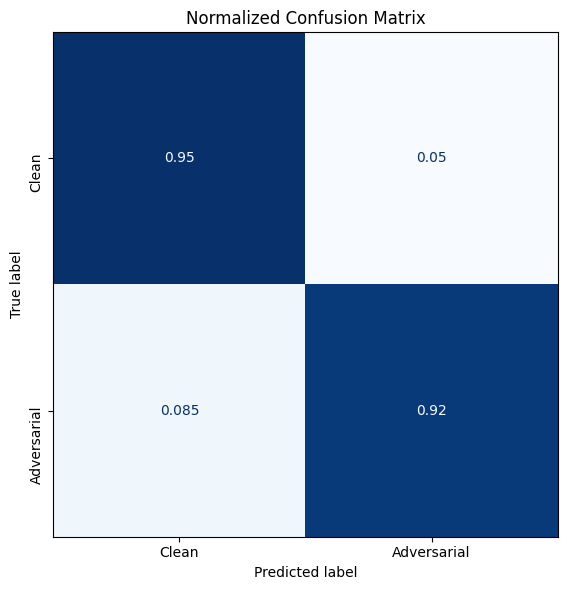

In [11]:
# Ensure numpy arrays
labels_test_np = np.array(labels_test).astype(int)
y_pred_np = np.array(y_pred)

# Squeeze prediction array to 1D and convert to int
y_pred_np = np.squeeze(y_pred_np).astype(int)

# Print classification report
print("Classification report\n%s" % classification_report(labels_test_np, y_pred_np))

# Compute and display normalized confusion matrix
cm = confusion_matrix(labels_test_np, y_pred_np, normalize='true')
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clean', 'Adversarial'])

fig, ax = plt.subplots(figsize=(8, 6))
display.plot(cmap='Blues', ax=ax, colorbar=False)
plt.yticks(rotation=90)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


In [12]:
number_adv_samples = np.sum(labels_test)
number_clean_samples = labels_test.size - number_adv_samples

print(f"Number of adversarial samples: {number_adv_samples}")
print(f"Number of clean samples: {number_clean_samples}")

Number of adversarial samples: 200.0
Number of clean samples: 200.0


In [ ]:
def get_accuracy(model, x_test, y_test):
    """
    Computes the number of correct predictions and total predictions for a given model and test set.

    Parameters:
    - model: The PyTorch model to evaluate.
    - x_test: Array or list of input samples to test (e.g., numpy array).
    - y_test: Array or list of true labels corresponding to x_test.

    Returns:
    - correct_predictions: Number of correct predictions made by the model.
    - total_predictions: Total number of predictions made.
    """
    model.eval()

    predictions = []
    true_values = []

    for x, y in zip(x_test, y_test):
        if x is None:
            print("None sample encountered")
            continue

        # Convert the input to a tensor and add a batch dimension
        x_tensor = torch.tensor(x).unsqueeze(0)

        with torch.no_grad():
            pred = model(x_tensor.to(device))

        pred_class = np.array(pred[0].detach().cpu().numpy()).argmax()
        predictions.append(pred_class)
        true_values.append(y)

    correct_predictions = sum(p == t for p, t in zip(predictions, true_values))
    total_predictions = len(true_values)

    return correct_predictions, total_predictions

**NN1 Accuracy Without Detector**

In [16]:
correct_predictions, total_predictions = get_accuracy(nn1, x_det_test, y_det_test)
accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
print(f"Accuracy without detector : {accuracy * 100:.2f}%")
print(f"Support: {total_predictions}")

Accuracy without detector : 48.75%
Support: 400


**NN1 Accuracy With Detector**

In [17]:
def apply_detector_d2(model, test_dataset):
    """
    Filters out non-adversarial samples (classified as zero) and returns
    the samples and corresponding labels.

    Args:
        model: The trained adversarial detection model.
        test_dataset: A TensorDataset containing samples and labels.

    Returns:
        filtered_X: Array of non-adversarial samples.
        filtered_y: Array of labels corresponding to non-adversarial samples.
    """
    output_activation = Sigmoid()
    filtered_X = []
    filtered_y = []

    with torch.no_grad():
        for X, y in test_dataset:
            # Forward pass
            o = model(X.unsqueeze(0).to(device))
            o = output_activation(o)

            # Check if the sample is classified as non-adversarial (label zero)
            if (o.detach() <= 0.5).item():
                filtered_X.append(X.cpu().numpy())
                filtered_y.append(y.cpu().numpy())

    return np.array(filtered_X), np.array(filtered_y)

In [18]:
model = build_adv_detector(1)
weights_path = './detector/fold_0_best_model.pth'
model.load_state_dict(torch.load(weights_path))
model.to(device)
model.eval()

X_tensor_test = torch.tensor(x_det_test)
y_tensor_test = torch.tensor(y_det_test)

test_dataset = TensorDataset(X_tensor_test, y_tensor_test)

# Filter out non-adversarial samples
filtered_X, filtered_y = apply_detector_d2(model, test_dataset)

# Calculate accuracy with the detector
correct_predictions, total_predictions = get_accuracy(nn1, filtered_X, filtered_y)
accuracy_det = correct_predictions / total_predictions if total_predictions > 0 else 0
print(f"Accuracy with detector: {accuracy_det * 100:.2f}%")
print(f"Support: {total_predictions}")

c:\Users\Utente\Desktop\AI For Cybersecurity\Code\AIenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utente\Desktop\AI For Cybersecurity\Code\AIenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy with detector: 87.44%
Support: 207


**Number of sample misclassified as adversarial sample**

In [20]:
model = build_adv_detector(1)
weights_path = './detector/fold_0_best_model.pth'
model.load_state_dict(torch.load(weights_path))
model.to(device)
model.eval()

X_tensor_test = torch.tensor(x_test)
y_tensor_test = torch.tensor(y_test)

test_dataset = TensorDataset(X_tensor_test, y_tensor_test)

# Filter out non-adversarial samples
filtered_X, filtered_y = apply_detector_d2(model, test_dataset)

print("Number of samples misclassified as adversarial samples: ", 1000-filtered_X.shape[0])

Number of samples misclassified as adversarial samples:  28
